LOAD DATA

In [4]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


UNDERSTAND DATA

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

DATA CLEANING

In [6]:
# FOR GRAPHS
df_raw = df.copy()

In [7]:
df = df.drop('customerID', axis=1)

In [8]:
# FIX DATA TYPES
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
# HANDLE MISSING VALUES
df = df.dropna()

In [10]:
df.fillna(method='ffill', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13176\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [11]:
# CONVERT CATEGORICAL TO NUMERIC
# #run this only for heatmap dont for graphs
df = pd.get_dummies(df, drop_first=True)

CREATE GRAPHS

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')


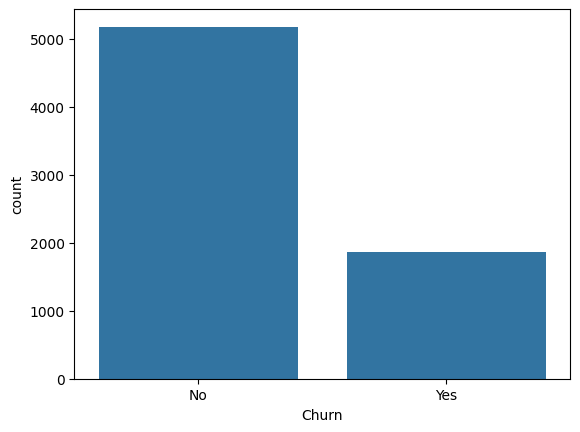

In [14]:
# Graph 1: Churn Distribution
# How many customers churned vs stayed
sns.countplot(x='Churn', data=df_raw)
plt.show()

most customers have stayed rather than churned

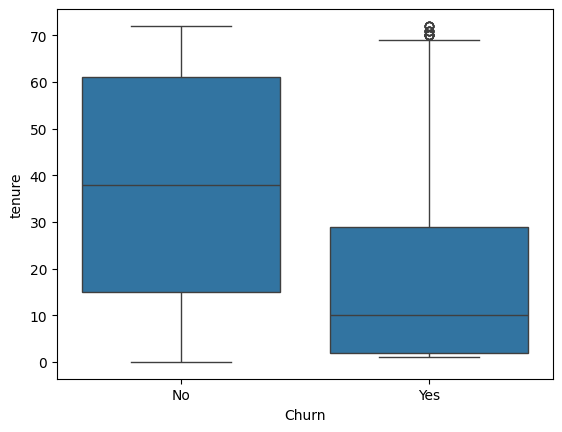

In [15]:
# Graph 2: Tenure vs Churn
# Do newer users churn more?
sns.boxplot(x="Churn", y='tenure', data=df_raw)
plt.show()

“The analysis shows that customers with shorter tenure have significantly higher churn rates, indicating that early-stage customer retention is critical. This suggests businesses should focus on improving onboarding and engagement strategies in the initial months.”

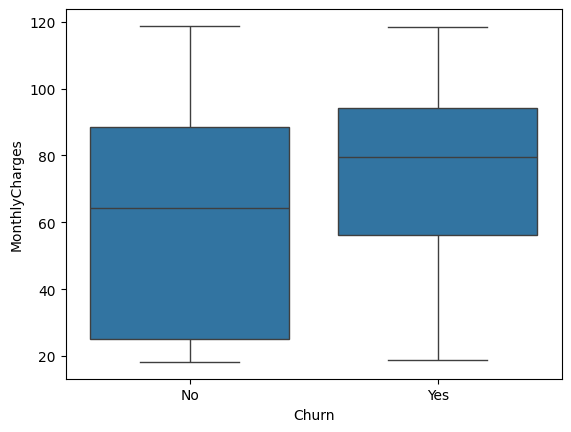

In [16]:
# Graph 3: Monthly Charges vs Churn
# Are high-paying users leaving?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_raw)
plt.show()

“Customers with higher monthly charges show a higher likelihood of churn, indicating that pricing sensitivity plays a significant role in customer retention.”

“High-value customers should be targeted with personalized retention strategies such as discounts, loyalty benefits, or enhanced service support to reduce churn risk.”

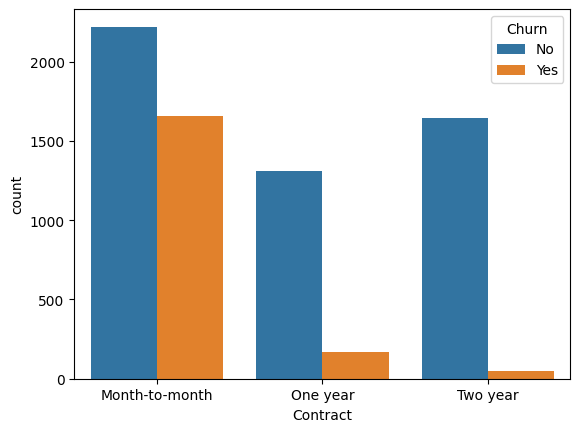

In [17]:
# Graph 4: Contract Type vs Churn
# Monthly vs Yearly plans impact
sns.countplot(x='Contract', hue='Churn', data=df_raw)
plt.xticks
plt.show()

“Customers on month-to-month contracts exhibit significantly higher churn rates compared to those on long-term contracts, indicating that lack of commitment increases the likelihood of customer attrition.”

“Encouraging customers to shift from month-to-month plans to longer-term contracts can significantly reduce churn and improve customer retention.”


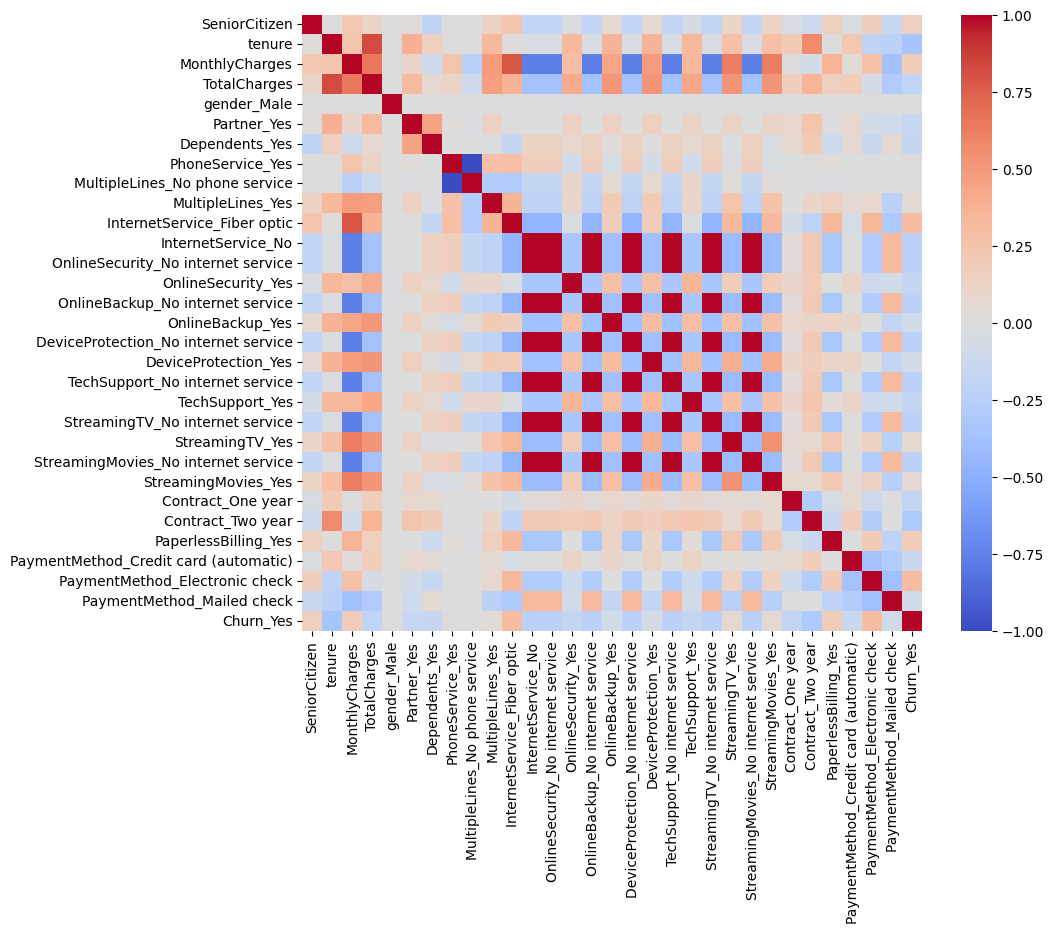

In [18]:
# Graph 5: Correlation Heatmap
# Which features strongly affect churn
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

“Some features showed multicollinearity, especially among service-related variables, which I considered while interpreting model results.”

“The correlation analysis shows that tenure and long-term contracts are strongly negatively correlated with churn, indicating higher customer retention. Additionally, higher monthly charges and certain payment methods show a positive correlation with churn. Service-related features also exhibit multicollinearity, suggesting overlapping information among variables.”

MODEL BUILDING

In [19]:
# STEP 1: SPLIT FEATURES & TARGET
# x = input features and y = what we predict (churn)

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [20]:
# STEP 2: TRAIN-TEST SPLIT
# train on 80% and test on unseen 20%

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# STEP 3: TRAIN LOGISTIC REGRESSION
# logistic regression bc it is simple, interpretable and works well for binary classification

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
# STEP 4: PREDICTIONS
y_pred = model.predict(X_test)

In [23]:
# STEP 5: EVALUATION
# ACCURACY
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.7853589196872779


In [24]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[917 116]
 [186 188]]


In [25]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.79      0.78      1407



In [26]:
# STEP 6: FEATURE IMPORTANCE

import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance.head(10))

                           Feature  Importance
10     InternetService_Fiber optic    0.571403
0                    SeniorCitizen    0.343595
26            PaperlessBilling_Yes    0.330750
8   MultipleLines_No phone service    0.251716
23             StreamingMovies_Yes    0.213967
9                MultipleLines_Yes    0.206755
21                 StreamingTV_Yes    0.188596
28  PaymentMethod_Electronic check    0.183681
5                      Partner_Yes    0.093680
2                   MonthlyCharges    0.006275


1. InternetService_Fiber optic (HIGH positive importance)

👉 Means:

Fiber optic users are more likely to churn
Why?
Higher cost
Higher expectations
Service dissatisfaction
2. SeniorCitizen

👉 Older users → more churn

Possible reasons:
Less tech comfort
Lower engagement
Price sensitivity
3. PaperlessBilling_Yes

👉 Users with paperless billing → more churn

Why?
Digital users = more flexible
Easier to switch providers

“Although features like tenure and contract type were strong indicators in EDA, their importance is distributed across encoded variables in the model.”

“The model results align with my EDA findings — factors like pricing, contract type, and customer behavior significantly influence churn. Additionally, features like fiber optic service and billing type highlight behavioral patterns in high-risk customers.”

In [27]:
# TOP NEGATIVE FEATURES
# These show: What REDUCES churn
print(feature_importance.tail(10))

                                  Feature  Importance
22    StreamingMovies_No internet service   -0.109165
11                     InternetService_No   -0.109165
27  PaymentMethod_Credit card (automatic)   -0.164766
15                       OnlineBackup_Yes   -0.181848
6                          Dependents_Yes   -0.232652
7                        PhoneService_Yes   -0.446679
24                      Contract_One year   -0.495675
13                     OnlineSecurity_Yes   -0.603961
19                        TechSupport_Yes   -0.605276
25                      Contract_Two year   -0.613789


“The model reveals that customer churn is influenced by both behavioral and service-related factors. High-risk customers include those with flexible contracts and higher charges, while retention is strongly driven by long-term contracts, value-added services like tech support, and automated payment methods.”